In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report, 
                           confusion_matrix, roc_auc_score, roc_curve)
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

In [3]:
# Load the dataset
def load_data():
    """
    Load the bank marketing dataset
    Note: You need to download the data from UCI repository first
    """
    # Load the data (adjust path as needed)
    try:
        # Try loading from local file
        df = pd.read_csv(r"C:\Data\Machine Learning\Machine_learning\Data\bank-full.csv", delimiter=';')
    except:
        # If file not found, try downloading from URL
        url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00222/bank.zip"
        # Alternative: use pandas to read from URL or use local file path
        print("Please download the dataset from UCI repository and load it locally")
        return None
    
    print("Dataset shape:", df.shape)
    print("\nDataset info:")
    print(df.info())
    print("\nFirst 5 rows:")
    print(df.head())
    
    return df

# Load and display basic info
df = load_data()

Dataset shape: (45211, 17)

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB
None

First 5 rows:
   age           job  marital  educat

In [5]:
def preprocess_data(df):
    """
    Preprocess the dataset for logistic regression
    """
    # Create a copy of the dataframe
    data = df.copy()
    
    # Display target variable distribution
    print("Target variable distribution:")
    print(data['y'].value_counts())
    print("\nTarget variable percentage:")
    print(data['y'].value_counts(normalize=True))
    
    # Convert target variable to binary
    data['y'] = data['y'].map({'yes': 1, 'no': 0})
    
    # Handle categorical variables - one-hot encoding
    categorical_columns = ['job', 'marital', 'education', 'contact', 'month', 'poutcome']
    data = pd.get_dummies(data, columns=categorical_columns, drop_first=True)
    
    # Handle binary categorical variables
    binary_columns = ['default', 'housing', 'loan']
    for col in binary_columns:
        data[col] = data[col].map({'yes': 1, 'no': 0})
    
    # Separate features and target
    X = data.drop('y', axis=1)
    y = data['y']
    
    print(f"\nFeatures shape: {X.shape}")
    print(f"Target shape: {y.shape}")
    
    return X, y

X, y = preprocess_data(df)


Target variable distribution:
y
no     39922
yes     5289
Name: count, dtype: int64

Target variable percentage:
y
no     0.883015
yes    0.116985
Name: proportion, dtype: float64

Features shape: (45211, 42)
Target shape: (45211,)


=== EXPLORATORY DATA ANALYSIS ===



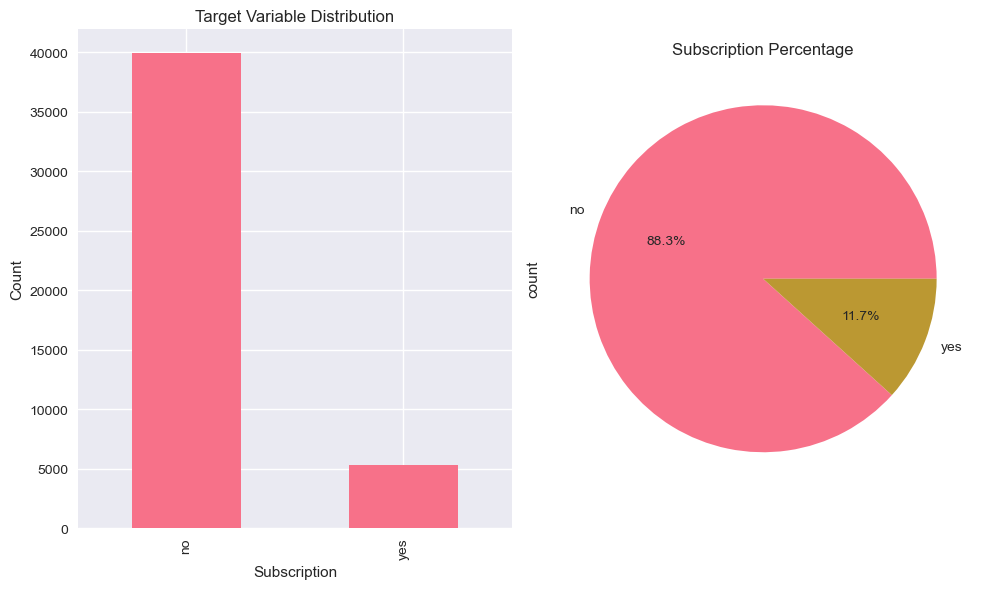

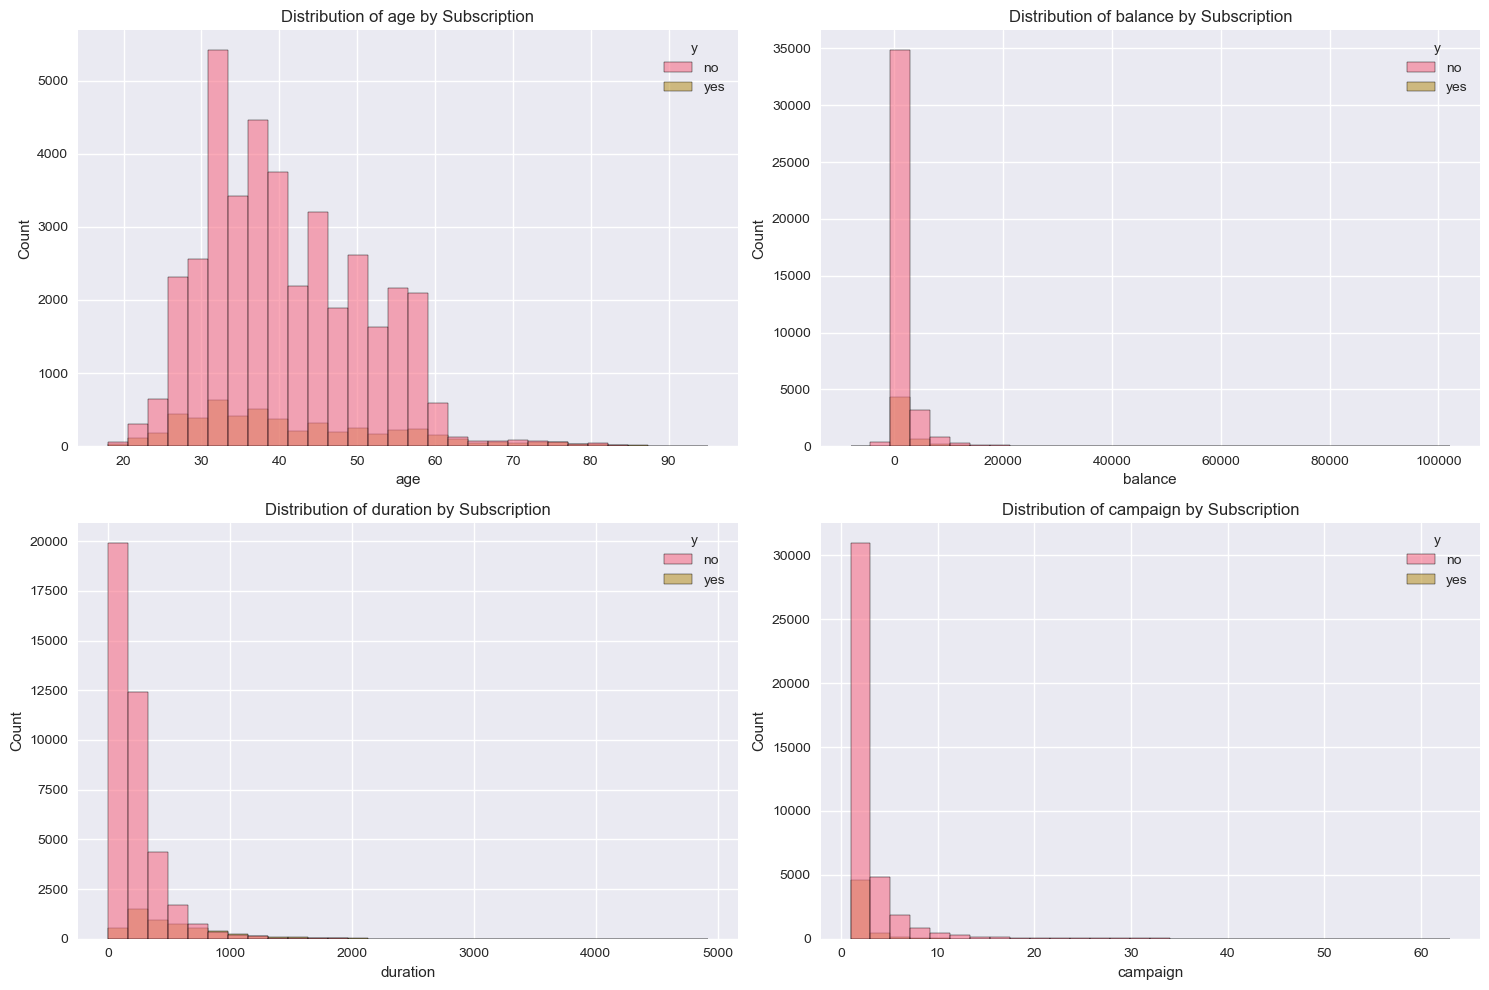

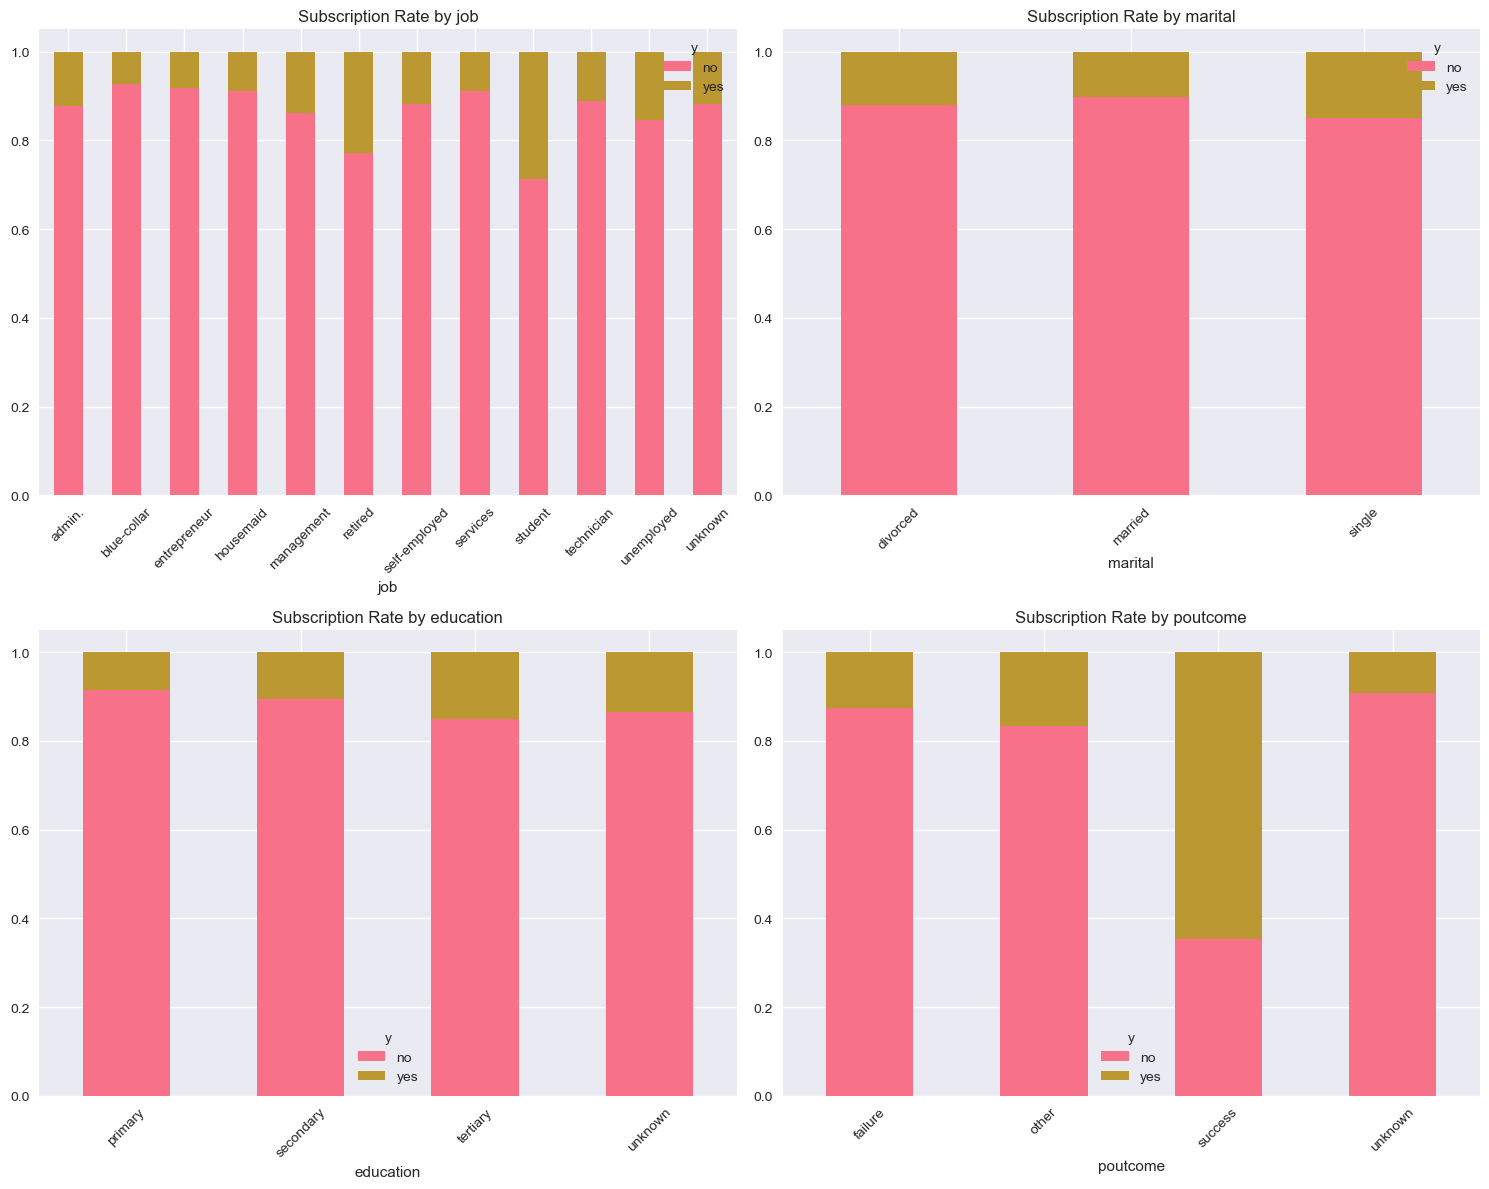

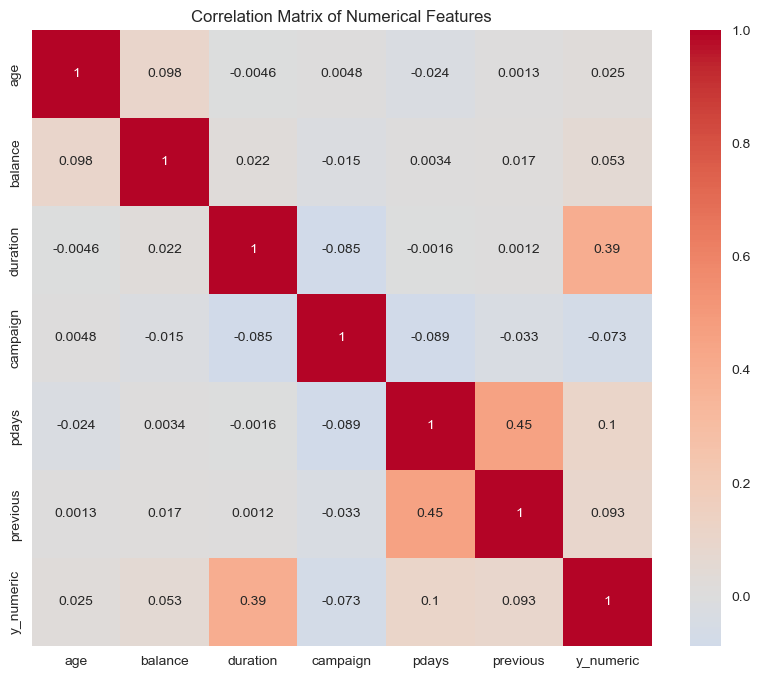

In [7]:
def perform_eda(df):
    """
    Perform Exploratory Data Analysis
    """
    print("=== EXPLORATORY DATA ANALYSIS ===\n")
    
    # 1. Target variable distribution
    plt.figure(figsize=(10, 6))
    plt.subplot(1, 2, 1)
    df['y'].value_counts().plot(kind='bar')
    plt.title('Target Variable Distribution')
    plt.xlabel('Subscription')
    plt.ylabel('Count')
    
    plt.subplot(1, 2, 2)
    df['y'].value_counts().plot(kind='pie', autopct='%1.1f%%')
    plt.title('Subscription Percentage')
    plt.tight_layout()
    plt.show()
    
    # 2. Numerical features distribution
    numerical_features = ['age', 'balance', 'duration', 'campaign']
    plt.figure(figsize=(15, 10))
    for i, feature in enumerate(numerical_features, 1):
        plt.subplot(2, 2, i)
        sns.histplot(data=df, x=feature, hue='y', bins=30, alpha=0.6)
        plt.title(f'Distribution of {feature} by Subscription')
    plt.tight_layout()
    plt.show()
    
    # 3. Categorical features analysis
    categorical_features = ['job', 'marital', 'education', 'poutcome']
    plt.figure(figsize=(15, 12))
    for i, feature in enumerate(categorical_features, 1):
        plt.subplot(2, 2, i)
        subscription_rate = df.groupby(feature)['y'].value_counts(normalize=True).unstack()
        subscription_rate.plot(kind='bar', stacked=True, ax=plt.gca())
        plt.title(f'Subscription Rate by {feature}')
        plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    
    # 4. Correlation analysis for numerical features
    numerical_df = df[['age', 'balance', 'duration', 'campaign', 'pdays', 'previous']].copy()
    numerical_df['y_numeric'] = df['y'].map({'yes': 1, 'no': 0})
    
    plt.figure(figsize=(10, 8))
    correlation_matrix = numerical_df.corr()
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
    plt.title('Correlation Matrix of Numerical Features')
    plt.show()

perform_eda(df)


In [9]:
def train_logistic_regression(X, y):
    """
    Train and evaluate logistic regression model
    """
    print("=== MODEL TRAINING AND EVALUATION ===\n")
    
    # Split the data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    print(f"Training set size: {X_train.shape[0]}")
    print(f"Test set size: {X_test.shape[0]}")
    
    # Scale the features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Train logistic regression model
    log_reg = LogisticRegression(
        random_state=42,
        max_iter=1000,
        class_weight='balanced'  # Handle class imbalance
    )
    
    log_reg.fit(X_train_scaled, y_train)
    
    # Make predictions
    y_pred = log_reg.predict(X_test_scaled)
    y_pred_proba = log_reg.predict_proba(X_test_scaled)[:, 1]
    
    return log_reg, scaler, X_test_scaled, y_test, y_pred, y_pred_proba

# Train the model
model, scaler, X_test_scaled, y_test, y_pred, y_pred_proba = train_logistic_regression(X, y)


=== MODEL TRAINING AND EVALUATION ===

Training set size: 36168
Test set size: 9043


=== MODEL EVALUATION ===

Accuracy: 0.846
AUC-ROC Score: 0.908

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.85      0.91      7985
           1       0.42      0.81      0.55      1058

    accuracy                           0.85      9043
   macro avg       0.70      0.83      0.73      9043
weighted avg       0.91      0.85      0.87      9043



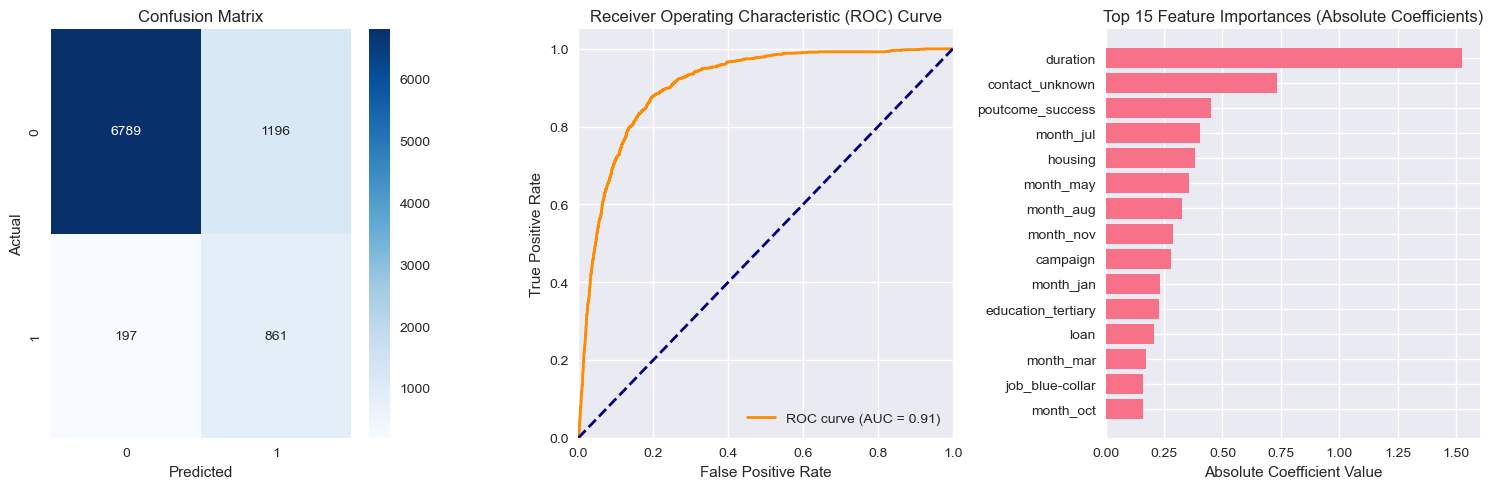

In [11]:
def evaluate_model(model, X_test, y_test, y_pred, y_pred_proba):
    """
    Comprehensive model evaluation
    """
    print("=== MODEL EVALUATION ===\n")
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    auc_roc = roc_auc_score(y_test, y_pred_proba)
    
    print(f"Accuracy: {accuracy:.3f}")
    print(f"AUC-ROC Score: {auc_roc:.3f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    
    # Confusion Matrix
    plt.figure(figsize=(15, 5))
    
    plt.subplot(1, 3, 1)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    
    # ROC Curve
    plt.subplot(1, 3, 2)
    fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc_roc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc="lower right")
    
    # Feature Importance
    plt.subplot(1, 3, 3)
    feature_importance = pd.DataFrame({
        'feature': X.columns,
        'importance': abs(model.coef_[0])  # Use absolute value for importance
    })
    feature_importance = feature_importance.sort_values('importance', ascending=True).tail(15)
    
    plt.barh(feature_importance['feature'], feature_importance['importance'])
    plt.title('Top 15 Feature Importances (Absolute Coefficients)')
    plt.xlabel('Absolute Coefficient Value')
    plt.tight_layout()
    plt.show()
    
    return accuracy, auc_roc

# Evaluate the model
accuracy, auc_roc = evaluate_model(model, X_test_scaled, y_test, y_pred, y_pred_proba)


=== FEATURE COEFFICIENT ANALYSIS ===

Top 10 Most Important Features:
             Feature  Coefficient  Abs_Coefficient
6           duration     1.526409         1.526409
27   contact_unknown    -0.733499         0.733499
40  poutcome_success     0.451346         0.451346
32         month_jul    -0.402798         0.402798
3            housing    -0.384133         0.384133
35         month_may    -0.355000         0.355000
28         month_aug    -0.328285         0.328285
36         month_nov    -0.289399         0.289399
7           campaign    -0.278326         0.278326
31         month_jan    -0.234466         0.234466


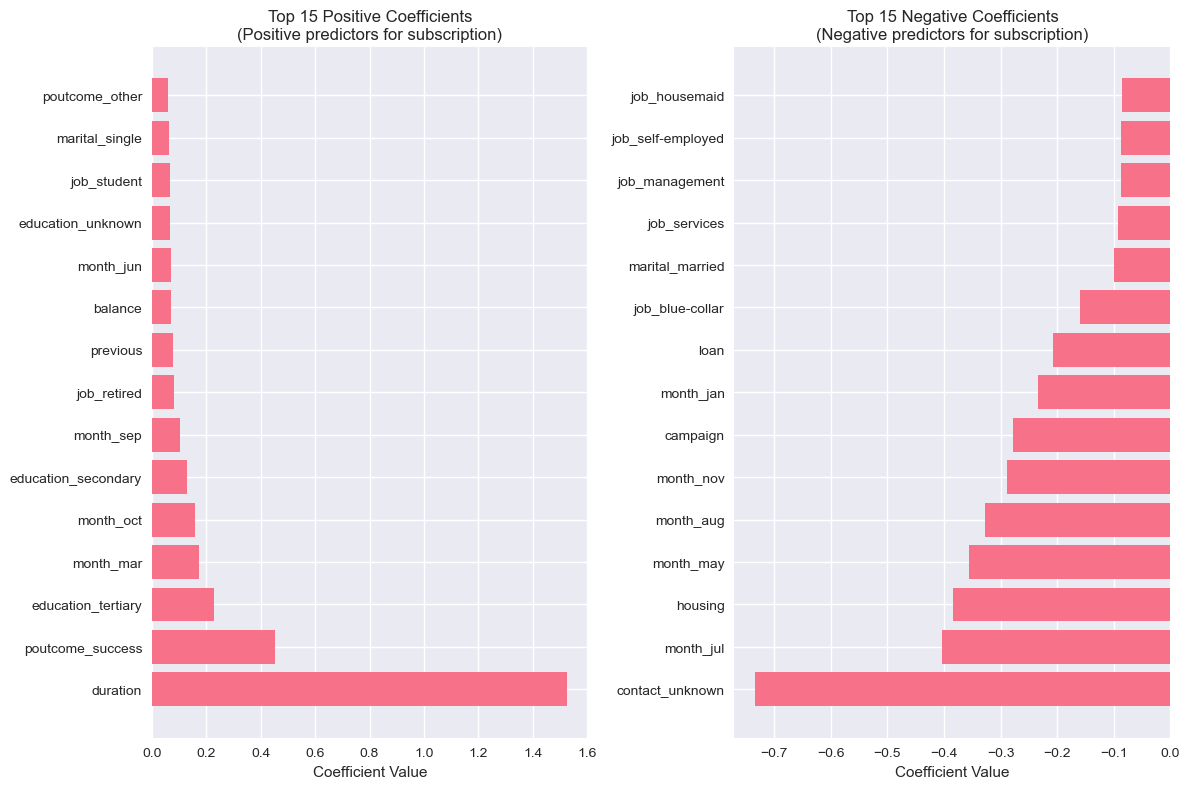

In [13]:
def analyze_feature_importance(model, X):
    """
    Analyze and display feature coefficients
    """
    print("=== FEATURE COEFFICIENT ANALYSIS ===\n")
    
    # Create coefficient dataframe
    coefficients = pd.DataFrame({
        'Feature': X.columns,
        'Coefficient': model.coef_[0]
    })
    
    # Sort by absolute value for importance
    coefficients['Abs_Coefficient'] = abs(coefficients['Coefficient'])
    coefficients = coefficients.sort_values('Abs_Coefficient', ascending=False)
    
    print("Top 10 Most Important Features:")
    print(coefficients.head(10))
    
    # Plot coefficients
    plt.figure(figsize=(12, 8))
    
    # Top 15 positive coefficients
    positive_coeff = coefficients[coefficients['Coefficient'] > 0].head(15)
    plt.subplot(1, 2, 1)
    plt.barh(positive_coeff['Feature'], positive_coeff['Coefficient'])
    plt.title('Top 15 Positive Coefficients\n(Positive predictors for subscription)')
    plt.xlabel('Coefficient Value')
    
    # Top 15 negative coefficients
    negative_coeff = coefficients[coefficients['Coefficient'] < 0].head(15)
    plt.subplot(1, 2, 2)
    plt.barh(negative_coeff['Feature'], negative_coeff['Coefficient'])
    plt.title('Top 15 Negative Coefficients\n(Negative predictors for subscription)')
    plt.xlabel('Coefficient Value')
    
    plt.tight_layout()
    plt.show()
    
    return coefficients

# Analyze feature importance
feature_coefficients = analyze_feature_importance(model, X)


In [15]:
def predict_subscription(model, scaler, customer_data, feature_names):
    """
    Predict subscription probability for new customer data
    """
    # Convert customer data to dataframe
    customer_df = pd.DataFrame([customer_data])
    
    # Ensure all features are present
    for feature in feature_names:
        if feature not in customer_df.columns:
            customer_df[feature] = 0
    
    # Reorder columns to match training data
    customer_df = customer_df[feature_names]
    
    # Scale the features
    customer_scaled = scaler.transform(customer_df)
    
    # Make prediction
    probability = model.predict_proba(customer_scaled)[0][1]
    prediction = model.predict(customer_scaled)[0]
    
    print(f"Subscription Probability: {probability:.3f}")
    print(f"Prediction: {'Will subscribe' if prediction == 1 else 'Will not subscribe'}")
    
    return probability, prediction

# Example usage:
# Define a sample customer (you would replace this with actual data)
sample_customer = {
    'age': 45,
    'balance': 5000,
    'duration': 300,
    'campaign': 1,
    'pdays': -1,
    'previous': 0,
    'default': 0,
    'housing': 0,
    'loan': 0,
    # Add other features with appropriate values
}

# Uncomment to test prediction
# predict_subscription(model, scaler, sample_customer, X.columns)


In [17]:
def generate_summary_report(accuracy, auc_roc, feature_coefficients):
    """
    Generate a summary report of the analysis
    """
    print("="*60)
    print("SUMMARY REPORT")
    print("="*60)
    
    print(f"\nModel Performance Summary:")
    print(f"• Accuracy: {accuracy:.3f}")
    print(f"• AUC-ROC Score: {auc_roc:.3f}")
    
    print(f"\nKey Positive Predictors (Higher probability of subscription):")
    positive_predictors = feature_coefficients[feature_coefficients['Coefficient'] > 0].head(5)
    for _, row in positive_predictors.iterrows():
        print(f"  • {row['Feature']}: {row['Coefficient']:.3f}")
    
    print(f"\nKey Negative Predictors (Lower probability of subscription):")
    negative_predictors = feature_coefficients[feature_coefficients['Coefficient'] < 0].head(5)
    for _, row in negative_predictors.iterrows():
        print(f"  • {row['Feature']}: {row['Coefficient']:.3f}")
    
    print(f"\nBusiness Recommendations:")
    print("1. Focus marketing efforts on clients with positive predictors")
    print("2. Consider reducing outreach to clients with strong negative predictors")
    print("3. Use the model to score client lists before campaigns")
    print("4. Monitor model performance regularly and retrain with new data")

# Generate final summary
generate_summary_report(accuracy, auc_roc, feature_coefficients)

SUMMARY REPORT

Model Performance Summary:
• Accuracy: 0.846
• AUC-ROC Score: 0.908

Key Positive Predictors (Higher probability of subscription):
  • duration: 1.526
  • poutcome_success: 0.451
  • education_tertiary: 0.226
  • month_mar: 0.172
  • month_oct: 0.158

Key Negative Predictors (Lower probability of subscription):
  • contact_unknown: -0.733
  • month_jul: -0.403
  • housing: -0.384
  • month_may: -0.355
  • month_aug: -0.328

Business Recommendations:
1. Focus marketing efforts on clients with positive predictors
2. Consider reducing outreach to clients with strong negative predictors
3. Use the model to score client lists before campaigns
4. Monitor model performance regularly and retrain with new data
